# Weight Pruning — Comet Sweep Analysis

Analyses for the 5 comet sweeps in `paper-weight-pruning-scaling-sweep`:

- **dense_fill_main**: block_sparse → dense fill experiment at n=16, h=256.
- **n_task_scaling**: block_sparse / dense / random_sparse / structure_search, each sweeping `task.n_tasks` × a size axis × LRs.

All sweeps log per-seed `(n_log_periods, n_seeds)` arrays as comet assets (`per_seed_losses.npy`, `per_seed_accs.npy`). Live metric series carry only the across-seed mean+std; the per-seed assets are loaded here to compute real 95% CI bands.

In [18]:
# # Run once to fetch from Comet. Comment out after first run.
# from phd.research_utils.scripts.comet_download import run as _comet_download
# # discovery_samples=10_000: scan every experiment for the param-name
# # discovery pass. Default (10) misses params that only appear on a small
# # subset of the project (e.g. dense_fill_main's model.dense_fill_step and
# # seed_offset, which sit on only ~7% of trials here).
# _comet_download(
#     project='paper-weight-pruning-scaling-sweep',
#     output_dir='data',
#     discovery_samples=10_000,
# )

In [19]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import t as t_dist

from comet_ml.api import API

from phd.research_utils.analysis.analysis_utils import (
    set_matplotlib_style, get_color_palette, save_fig_versions,
)
from phd.research_utils.analysis.plotting import (
    plot_param_sensitivity,
)

set_matplotlib_style('2-row')
%matplotlib inline

PROJECT = 'paper-weight-pruning-scaling-sweep'

# Some logical sweeps are split across multiple Comet sweep_ids -- e.g.
# dense_fill_main has an LR-range extension addendum sweep. List the
# constituent sweep names so they're merged in the analysis.
SWEEP_IDS = {
    'dense_fill_main':    ['dc6d3df68d25479999b72a32af29c275',
                           'e7f7b78ac77444b98eb133ffd25a6952'],  # main + LR-ext addendum
    'n_block_sparse':     ['bf92bf7c1ced4535823e892b8049089d'],
    'n_dense':            ['b21316aca20d4aa7b60d05f03d59babc'],
    'n_random_sparse':    ['ac0163f45597446fbdea4a12edffd3ab'],
    'n_structure_search': ['eb0849167ea44728a1173f9a794fd165'],
}
SWEEP_NAMES = {
    'dense_fill_main':    ['00_block_sparse_dense_fill_main_n16_h256',
                           '00_block_sparse_dense_fill_main_n16_h256_lrext'],
    'n_block_sparse':     ['00_block_sparse_n_task_scaling_lr_5seed'],
    'n_dense':            ['00_dense_n_task_scaling_lr_5seed'],
    'n_random_sparse':    ['00_random_sparse_n_task_scaling_lr_5seed'],
    'n_structure_search': ['00_structure_search_n_task_scaling_lr_5seed'],
}

DATA_DIR    = Path('data')
ASSET_CACHE = DATA_DIR / 'per_seed_cache'
ASSET_CACHE.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    save_fig_versions(name, dir='figures/pdf/', type='pdf')
    save_fig_versions(name, dir='figures/png/', type='png')

## Load data

`comet_download` dumps two CSVs: one with per-trial parameters, one with the metric history. The metric history uses Comet's `step` index, which the train script sets to the global training step at each log period.

In [20]:
PARAMS_PATH  = DATA_DIR / f'{PROJECT}_params.csv'
METRICS_PATH = DATA_DIR / f'{PROJECT}_metrics.csv'

cfg_all = pd.read_csv(PARAMS_PATH, index_col=0)
run_all = pd.read_csv(METRICS_PATH, index_col=0)

# Sweep-axis params are logged twice by comet_download: the `foo.bar` dotted
# form is the raw CLI-override string (which may still contain unevaluated
# `${eval:...}` interpolations), while the `foo|bar` pipe form is the
# resolved value from the Hydra cfg. Prefer the pipe form when available.
_PIPE_TO_DOTTED = {
    'task|n_tasks':                          'task.n_tasks',
    'task|permute_period':                   'task.permute_period',
    'model|initial_hidden_units':            'model.initial_hidden_units',
    'model|max_hidden_units':                'model.max_hidden_units',
    'optimizer|learning_rate':               'optimizer.learning_rate',
    'structure_search|connection_budget':    'structure_search.connection_budget',
    'structure_search|prune_count':          'structure_search.prune_count',
    'structure_search|max_units_per_event':  'structure_search.max_units_per_event',
    'train|log_freq':                        'train.log_freq',
    'train|total_steps':                     'train.total_steps',
    'train|batch_size':                      'train.batch_size',
}
for pipe, dotted in _PIPE_TO_DOTTED.items():
    if pipe in cfg_all.columns:
        cfg_all[dotted] = cfg_all[pipe]

_NUMERIC_COLS = [
    'task.n_tasks', 'model.initial_hidden_units', 'model.max_hidden_units',
    'model.dense_fill_step', 'structure_search.connection_budget',
    'structure_search.prune_count', 'structure_search.max_units_per_event',
    'optimizer.learning_rate', 'seed_offset', 'train.log_freq',
    'train.total_steps',
]
for col in _NUMERIC_COLS:
    if col in cfg_all.columns:
        cfg_all[col] = pd.to_numeric(cfg_all[col], errors='coerce')

# The metrics CSV from comet_download has no explicit `step` column -- rows
# are pre-sorted per run_id by Comet's step index. Reconstruct step from
# (row position within run_id) * log_freq, using each trial's own log_freq.
run_all = run_all.reset_index(drop=True)
log_freq_map = cfg_all.set_index('run_id')['train.log_freq'].to_dict()
run_all['_log_freq'] = run_all['run_id'].map(log_freq_map).astype(float)
run_all['step'] = (run_all.groupby('run_id').cumcount() + 1) * run_all['_log_freq']
run_all = run_all.drop(columns='_log_freq').dropna(subset=['step'])

print(f'{len(cfg_all)} trials, {len(run_all)} metric rows')
print('\nsweep_name counts:')
print(cfg_all['sweep_name'].value_counts())

620 trials, 246238 metric rows

sweep_name counts:
sweep_name
00_dense_n_task_scaling_lr_5seed                  174
00_block_sparse_n_task_scaling_lr_5seed           145
00_structure_search_n_task_scaling_lr_5seed       130
00_random_sparse_n_task_scaling_lr_5seed          126
00_block_sparse_dense_fill_main_n16_h256           32
00_block_sparse_dense_fill_main_n16_h256_lrext     13
Name: count, dtype: int64


## Helpers

In [21]:
# Cell-coordinate registry: which params define a unique experimental cell
# in each sweep. Comet retries from time-outs / crashes show up as multiple
# trials at the same cell; everything downstream dedupes on these columns.
SWEEP_CELL_COLS = {
    'dense_fill_main': [
        'task.n_tasks', 'model.initial_hidden_units', 'model.dense_fill_step',
        'seed_offset', 'optimizer.learning_rate',
    ],
    'n_block_sparse':     ['task.n_tasks', 'model.initial_hidden_units',
                           'optimizer.learning_rate'],
    'n_dense':            ['task.n_tasks', 'model.initial_hidden_units',
                           'optimizer.learning_rate'],
    'n_random_sparse':    ['task.n_tasks', 'model.initial_hidden_units',
                           'optimizer.learning_rate'],
    'n_structure_search': ['task.n_tasks', 'structure_search.connection_budget',
                           'optimizer.learning_rate'],
}


def _diverged_run_ids(run):
    """Run_ids whose `diverged` summary metric is set (> 0.5)."""
    if 'diverged' not in run.columns:
        return set()
    last_div = run.groupby('run_id')['diverged'].apply(
        lambda s: s.dropna().iloc[-1] if s.notna().any() else 0
    )
    return set(last_div[last_div > 0.5].index)


def _annotate_trials(cfg, run):
    """Augment cfg with per-trial diagnostics: n_rows, expected, div_flag,
    completed (= ran to full row count OR flagged diverged)."""
    out = cfg.copy()
    rc = run.groupby('run_id').size().rename('n_rows')
    ld = run.groupby('run_id')['diverged'].apply(
        lambda s: s.dropna().iloc[-1] if s.notna().any() else 0
    ).rename('div_flag') if 'diverged' in run.columns else pd.Series(name='div_flag', dtype=float)
    out = out.merge(rc, left_on='run_id', right_index=True, how='left')
    out = out.merge(ld, left_on='run_id', right_index=True, how='left')
    out['n_rows']   = out['n_rows'].fillna(0).astype(int)
    out['div_flag'] = out['div_flag'].fillna(0)
    out['expected'] = (out['train.total_steps'] / out['train.log_freq']).fillna(0).astype(int)
    out['completed'] = (out['n_rows'] >= out['expected']) | (out['div_flag'] > 0.5)
    return out


def _dedupe_trials(cfg, run, cell_cols):
    """Drop duplicate Comet trials per cell, keeping the best attempt.

    Sort by (completed desc, n_rows desc) so the first row after dedup is the
    most-complete trial; the rest are retries that we want to ignore so they
    don't get NaN-propagated through the aggregation.
    """
    annotated = _annotate_trials(cfg, run)
    annotated = annotated.sort_values(['completed', 'n_rows'], ascending=[False, False])
    dedup = annotated.drop_duplicates(subset=cell_cols, keep='first')
    dedup_cfg = dedup.drop(columns=['n_rows', 'expected', 'div_flag', 'completed'])
    dedup_run = run[run['run_id'].isin(dedup_cfg['run_id'])]
    return dedup_cfg, dedup_run


def filter_sweep(key, dedup=True):
    """Slice cfg+run to one logical sweep by short key (e.g. 'n_block_sparse').

    A logical sweep can span multiple Comet sweep_ids (see SWEEP_NAMES) -- the
    dense_fill_main sweep has an LR-range extension addendum that merges in
    here. When dedup=True (default), keeps one trial per experimental cell so
    Comet retries from time-outs/crashes don't pollute the aggregation. Dedup
    happens AFTER the merge so retries across addendum sweeps also dedupe.
    """
    targets = SWEEP_NAMES[key]
    if isinstance(targets, str):
        targets = [targets]
    cfg = cfg_all[cfg_all['sweep_name'].isin(targets)].copy()
    run = run_all[run_all['run_id'].isin(cfg['run_id'])].copy()
    if dedup and key in SWEEP_CELL_COLS:
        cfg, run = _dedupe_trials(cfg, run, SWEEP_CELL_COLS[key])
    return cfg, run


def asymptotic_metric(cfg, run, metric_col, group_cols):
    """Mean of `metric_col` over the last 5% of training steps per trial, then
    aggregated per (group, LR). NaN-propagating: a diverged or NaN trial
    yields NaN per-trial, and any NaN within a (group, LR) cell makes the
    whole cell NaN (so cells with any bad run show up as gaps in plots).
    """
    diverged = _diverged_run_ids(run)
    per_run = (
        run.groupby('run_id')[metric_col]
        .apply(lambda s: (
            s.dropna().iloc[max(1, int(0.95 * len(s.dropna()))):].mean()
            if len(s.dropna()) > 1 else np.nan
        ))
        .rename('_metric')
    )
    if diverged:
        per_run.loc[per_run.index.intersection(diverged)] = np.nan
    merged = cfg.merge(per_run, left_on='run_id', right_index=True, how='left')
    return (
        merged.groupby(group_cols + ['optimizer.learning_rate'])['_metric']
        .agg(lambda x: x.mean(skipna=False))    # propagate NaN within a cell
        .reset_index()
    )


def filter_to_best(cfg, run, group_cols, metric_col, direction='max'):
    """Keep only the rows whose LR is best within each group (NaN-aware)."""
    asym = asymptotic_metric(cfg, run, metric_col, group_cols)
    grouped = asym.groupby(group_cols)['_metric']
    idxs = (grouped.idxmax() if direction == 'max' else grouped.idxmin()).dropna()
    best = asym.loc[idxs.astype(int)]
    keep = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    cfg_keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    mask = pd.Series([k in keep for k in cfg_keys], index=cfg.index)
    return cfg[mask].copy(), run[run['run_id'].isin(cfg.loc[mask, 'run_id'])].copy(), best


def report_cell_coverage(expected_configspace_sizes):
    """For each logical sweep: expected configspace size vs. unique completed cells.

    Logical sweeps spanning multiple Comet sweep_ids are reported merged
    (matching how filter_sweep treats them).
    """
    bar = '=' * 78
    for key, names in SWEEP_NAMES.items():
        if isinstance(names, str):
            names = [names]
        cfg_s = cfg_all[cfg_all['sweep_name'].isin(names)]
        run_s = run_all[run_all['run_id'].isin(cfg_s['run_id'])]
        if len(cfg_s) == 0:
            continue
        annotated = _annotate_trials(cfg_s, run_s)
        cell_cols = SWEEP_CELL_COLS.get(key)
        if cell_cols is None:
            continue
        annotated = annotated.sort_values(['completed', 'n_rows'],
                                          ascending=[False, False])
        dedup = annotated.drop_duplicates(subset=cell_cols, keep='first')
        expected = expected_configspace_sizes.get(key, np.nan)
        n_trials = len(annotated)
        n_dupes = n_trials - len(dedup)
        n_completed = int(dedup['completed'].sum())
        n_incomplete = int((~dedup['completed']).sum())
        n_missing = (expected - len(dedup)) if pd.notna(expected) else np.nan
        component_str = (', '.join(names) if len(names) > 1
                         else names[0]) if names else ''

        print(f'\n{bar}')
        print(f' {key}  -- {component_str}')
        print(f'{bar}')
        print(f'  expected cells (configspace): {expected}')
        print(f'  total trials logged:          {n_trials}  (duplicates discarded: {n_dupes})')
        print(f'  cells with a completed trial: {n_completed}')
        print(f'  cells missing entirely:       {n_missing}'
              + ('  (these are the expected-fail h<n_tasks cells for block_sparse)'
                 if key == 'n_block_sparse' else ''))
        print(f'  cells with only INCOMPLETE attempts: {n_incomplete}')

        if n_incomplete > 0:
            print(f'\n  !! These {n_incomplete} cell(s) have no completed trial -- their')
            print(f'  !! asymptotic comes from a truncated tail. Investigate or re-run:\n')
            bad = dedup[~dedup['completed']].copy()
            # Truncate (don't round) so 498/500 reads 99% not 100%.
            bad['pct'] = (100 * bad['n_rows'] / bad['expected']).astype(int).astype(str) + '%'
            bad['likely_cause'] = np.where(
                bad['n_rows'] < 0.5 * bad['expected'],
                'silent crash / undetected divergence',
                'SLURM walltime hit',
            )
            cols_show = cell_cols + ['n_rows', 'expected', 'pct',
                                     'div_flag', 'likely_cause']
            with pd.option_context('display.width', 200, 'display.max_columns', None):
                print(bad[cols_show].to_string(index=False))


def plot_lr_sensitivity(asym, ax, x_col='optimizer.learning_rate', y_col='_metric',
                        hue_col=None, palette=None, title='', xlabel='Learning rate',
                        ylabel='Asymptotic metric', ylim=None, legend_title=None):
    """Asymptotic metric vs LR on a log-2 x-axis, with NaN-gap-aware lines.

    Legend fontsize is *not* set here -- it inherits the global rcParams
    (e.g. ``legend.fontsize=15`` from set_matplotlib_style('2-row')) so this
    helper matches the styling in weight_pruning_scaling_analysis.ipynb.
    """
    if hue_col is None:
        sub = asym.sort_values(x_col)
        ax.plot(sub[x_col], sub[y_col], '-o', color='C0')
    else:
        try:
            hue_vals = sorted(asym[hue_col].dropna().unique(),
                              key=lambda v: float(v))
        except Exception:
            hue_vals = sorted(asym[hue_col].dropna().unique())
        if palette is None:
            colors = sns.color_palette('viridis', n_colors=len(hue_vals))
        else:
            colors = list(palette)
        for hv, color in zip(hue_vals, colors):
            sub = asym[asym[hue_col] == hv].sort_values(x_col)
            # Numeric hue values get a "1,234" comma-grouped label; strings
            # (e.g. method names) pass through as-is.
            try:
                label = (f'{int(hv):,}' if float(hv).is_integer() else f'{hv}')
            except (TypeError, ValueError):
                label = str(hv)
            ax.plot(sub[x_col], sub[y_col], '-o', color=color, label=label)
        ax.legend(title=legend_title or hue_col, loc='best')
    ax.set_xscale('log', base=2)
    lr_vals = sorted(asym[x_col].dropna().unique())
    ax.set_xticks(lr_vals)
    ax.set_xticklabels([f'$2^{{{int(np.log2(v))}}}$' for v in lr_vals])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.4)

In [22]:
# Per-seed asset loader (cached + concurrent).
_api_singleton = None
def _api():
    global _api_singleton
    if _api_singleton is None:
        _api_singleton = API()
    return _api_singleton


def fetch_per_seed_arrays(run_ids, n_threads=8):
    """Download per_seed_losses + per_seed_accs for a set of run_ids; cached on disk.

    Returns: dict run_id -> {'losses': arr, 'accs': arr}, each (n_log_periods, n_seeds).
    """
    def fetch_one(run_id):
        cache_l = ASSET_CACHE / f'{run_id}_losses.npy'
        cache_a = ASSET_CACHE / f'{run_id}_accs.npy'
        if cache_l.exists() and cache_a.exists():
            return run_id, {'losses': np.load(cache_l), 'accs': np.load(cache_a)}
        try:
            e = _api().get_experiment_by_key(run_id)
            asset_list = e.get_asset_list()
            by_name = {a['fileName']: a for a in asset_list}
            for asset_name, cache_path in [
                ('per_seed_losses.npy', cache_l),
                ('per_seed_accs.npy',  cache_a),
            ]:
                if asset_name not in by_name:
                    return run_id, None
                data = e.get_asset(by_name[asset_name]['assetId'], return_type='binary')
                arr = np.load(io.BytesIO(data))
                np.save(cache_path, arr)
            return run_id, {'losses': np.load(cache_l), 'accs': np.load(cache_a)}
        except Exception as exc:
            print(f'failed for {run_id}: {exc}')
            return run_id, None

    out = {}
    with ThreadPoolExecutor(max_workers=n_threads) as ex:
        futures = {ex.submit(fetch_one, rid): rid for rid in run_ids}
        for f in tqdm(as_completed(futures), total=len(futures), desc='fetch per-seed'):
            rid, data = f.result()
            if data is not None:
                out[rid] = data
    return out


def stack_per_seed(asset_dict, run_ids):
    """Concat per-seed arrays across a list of run_ids along the seed axis.

    Diverged trials produce *shorter* arrays (the train script early-stops).
    To keep all trials at the same step axis we NaN-pad shorter arrays up to
    the longest length present. With NaN-propagating mean (see plot_ci_curve),
    a single diverged trial nullifies the combined curve past its divergence
    step, so the curve simply ends where any constituent trial ended.

    Returns: (losses, accs), shape (max_n_periods, n_combined_seeds).
    """
    present = [rid for rid in run_ids if rid in asset_dict]
    if not present:
        return None, None
    max_len = max(asset_dict[rid]['losses'].shape[0] for rid in present)

    def pad(arr):
        if arr.shape[0] == max_len:
            return arr
        pad_block = np.full((max_len - arr.shape[0], arr.shape[1]), np.nan,
                            dtype=arr.dtype)
        return np.concatenate([arr, pad_block], axis=0)

    losses = np.concatenate([pad(asset_dict[rid]['losses']) for rid in present], axis=1)
    accs   = np.concatenate([pad(asset_dict[rid]['accs'])   for rid in present], axis=1)
    return losses, accs


def plot_ci_curve(steps, arr, label=None, color=None, alpha=0.20, ax=None):
    """Mean + 95% t-CI band from a (n_periods, n_seeds) array (NaN-propagating).

    A single NaN seed at step t makes mean[t] = NaN, so the line and band
    end at the earliest divergence among the constituent seeds. No silent
    skipping of divergent seeds.
    """
    ax = ax or plt.gca()
    mean = arr.mean(axis=1)           # propagate NaN
    sem  = arr.std(axis=1, ddof=1) / np.sqrt(arr.shape[1])
    half_w = t_dist.ppf(0.975, df=arr.shape[1] - 1) * sem
    ax.plot(steps, mean, label=label, color=color)
    ax.fill_between(steps, mean - half_w, mean + half_w,
                    alpha=alpha, color=color, linewidth=0)

In [23]:
# Coverage report: for each sweep, expected configspace size vs. unique
# completed cells. Duplicates (Comet retries) are discarded -- we keep the
# most-complete trial per cell so the rest of the notebook works off a
# unique-per-cell view.
#
# Expected configspace sizes match the registered Comet sweep yamls:
#   dense_fill_main:    main 30 + lr-ext addendum 12               = 42
#   n_block_sparse:     5 n x 8 hidden x 4 LR                      = 160
#   n_dense:            5 n x 8 hidden x 4 LR                      = 160
#   n_random_sparse:    5 n x 6 hidden x 4 LR                      = 120
#   n_structure_search: 5 n x 6 budget x 4 LR                      = 120
EXPECTED_CONFIGSPACE = {
    'dense_fill_main':    42,
    'n_block_sparse':     160,
    'n_dense':            160,
    'n_random_sparse':    120,
    'n_structure_search': 120,
}
report_cell_coverage(EXPECTED_CONFIGSPACE)


 dense_fill_main  -- 00_block_sparse_dense_fill_main_n16_h256, 00_block_sparse_dense_fill_main_n16_h256_lrext
  expected cells (configspace): 42
  total trials logged:          45  (duplicates discarded: 3)
  cells with a completed trial: 41
  cells missing entirely:       0
  cells with only INCOMPLETE attempts: 1

  !! These 1 cell(s) have no completed trial -- their
  !! asymptotic comes from a truncated tail. Investigate or re-run:

 task.n_tasks  model.initial_hidden_units  model.dense_fill_step  seed_offset  optimizer.learning_rate  n_rows  expected pct  div_flag       likely_cause
           16                         256                    0.0          0.0                 0.000977     498       500 99%       0.0 SLURM walltime hit

 n_block_sparse  -- 00_block_sparse_n_task_scaling_lr_5seed
  expected cells (configspace): 160
  total trials logged:          145  (duplicates discarded: 9)
  cells with a completed trial: 132
  cells missing entirely:       24  (these are the exp

## 1. dense_fill_main

n_tasks=16, hidden_units=256, total_steps=500k. The grid is `(dense_fill_step ∈ {0, 250000, 600000}) × (LR ∈ {2^-11..2^-7}) × (seed_offset ∈ {0, 15})`. 600000 is the never-fill sentinel (block_sparse baseline), 0 = dense-from-start with cross-task weights initially 0.

In [24]:
df_cfg, df_run = filter_sweep('dense_fill_main')
df_run['loss_per_task'] = df_run['loss'] / 16
print(f'{len(df_cfg)} trials')

# Sanity: should be 3 fill steps × 5 LRs × 2 seed_offsets = 30 trials.
print(df_cfg.groupby(['model.dense_fill_step', 'seed_offset']).size())

42 trials
model.dense_fill_step  seed_offset
0.0                    0.0            7
                       15.0           7
250000.0               0.0            7
                       15.0           7
600000.0               0.0            7
                       15.0           7
dtype: int64


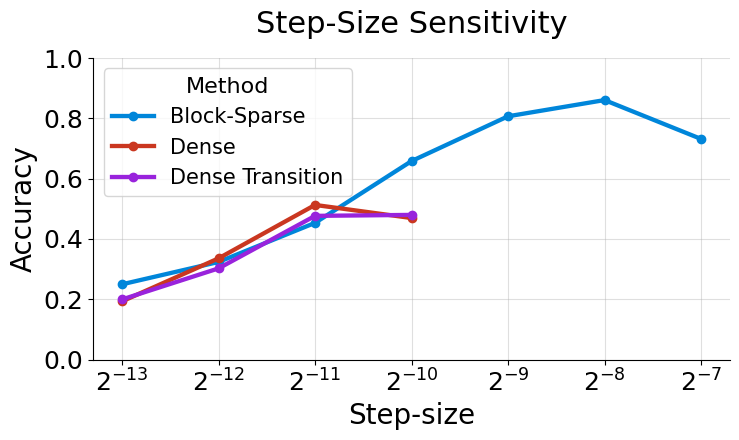

optimizer.learning_rate  0.000122  0.000244  0.000488  0.000977  0.001953  \
Method                                                                      
Block-Sparse                0.250     0.324     0.453     0.658     0.807   
Dense                       0.193     0.336     0.513     0.469       NaN   
Dense Transition            0.199     0.302     0.476     0.480       NaN   

optimizer.learning_rate  0.003906  0.007812  
Method                                       
Block-Sparse                 0.86     0.732  
Dense                         NaN       NaN  
Dense Transition              NaN       NaN  


In [25]:
# Method labels and project-palette colors for the three fill_step values.
# Matches weight_pruning_scaling_analysis.ipynb: blue=block-sparse,
# red=dense, purple for the best-LR dense-transition variant. The
# matched-LR variant in cell 5406aa32 uses green to set it apart.
from phd.research_utils.analysis.analysis_utils import get_color_palette
_PAL = get_color_palette()
FILL_STEP_LABELS = {0: 'Dense', 250000: 'Dense Transition', 600000: 'Block-Sparse'}
FILL_STEP_PALETTE = {
    'Block-Sparse':     _PAL[0],   # blue
    'Dense':            _PAL[1],   # red
    'Dense Transition': _PAL[3],   # purple
}

# LR sensitivity (NaN-propagating: cells whose underlying trial diverged
# show no point and create a gap in the line).
asym = asymptotic_metric(df_cfg, df_run, 'accuracy',
                         group_cols=['model.dense_fill_step'])
asym['Method'] = asym['model.dense_fill_step'].map(FILL_STEP_LABELS)

# Sorted hue order is alphabetical: Block-Sparse, Dense, Dense Transition.
fill_palette_list = [FILL_STEP_PALETTE[m] for m in sorted(FILL_STEP_PALETTE)]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_lr_sensitivity(
    asym, ax=ax,
    hue_col='Method', palette=fill_palette_list,
    title='Step-Size Sensitivity',
    xlabel='Step-size', ylabel='Accuracy',
    ylim=(0, 1), legend_title='Method',
)
plt.tight_layout()
save_fig('dense_fill_main_lr_sensitivity')
plt.show()

# Print the underlying values so you can see which cells diverged.
print(asym.pivot(index='Method', columns='optimizer.learning_rate',
                 values='_metric').round(3))

In [26]:
# Best LR per fill_step; pull the corresponding two seed_offset halves.
best_cfg, best_run, best = filter_to_best(
    df_cfg, df_run, group_cols=['model.dense_fill_step'],
    metric_col='accuracy', direction='max',
)
print('best LR per fill_step:')
print(best)

# Should be 6 trials (3 fill_step × 2 seed_offset).
asset_dict = fetch_per_seed_arrays(best_cfg['run_id'].tolist())

best LR per fill_step:
    model.dense_fill_step  optimizer.learning_rate   _metric
2                     0.0                 0.000488  0.512681
10               250000.0                 0.000977  0.479651
19               600000.0                 0.003906  0.860443


fetch per-seed: 100%|██████████| 6/6 [00:00<00:00, 9773.14it/s]


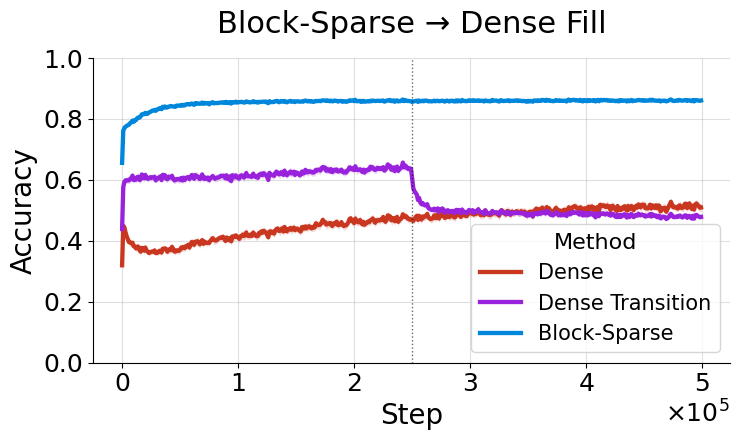

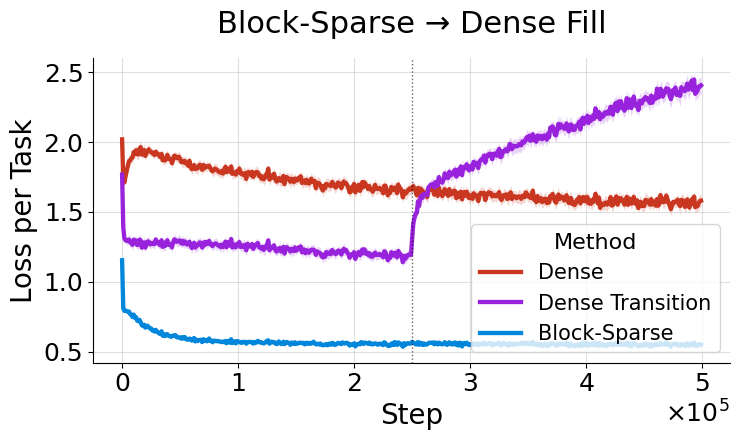

In [27]:
import matplotlib.ticker as mticker

fill_steps = sorted(best_cfg['model.dense_fill_step'].unique())

def _draw_method_curves(ax, accs_axis: bool):
    """Plot the 3 best-LR-per-method curves (Block-Sparse, Dense, Dense Transition)."""
    for fs in fill_steps:
        rids = best_cfg[best_cfg['model.dense_fill_step'] == fs]['run_id'].tolist()
        losses, accs = stack_per_seed(asset_dict, rids)
        if losses is None:
            continue
        steps = np.arange(losses.shape[0]) * 1000
        method = FILL_STEP_LABELS[int(fs)]
        arr = accs if accs_axis else losses / 16
        plot_ci_curve(steps, arr, label=method,
                      color=FILL_STEP_PALETTE[method], ax=ax)
    # Black dotted vertical line at the Dense Transition fill step.
    ax.axvline(250000, linestyle=':', color='black', alpha=0.6, linewidth=1)
    # useMathText renders the offset as ×10⁵ (bottom-right) instead of `1e5`.
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    ax.set_xlabel('Step')
    ax.grid(True, alpha=0.4)

# --- Accuracy ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
_draw_method_curves(ax, accs_axis=True)
ax.set_ylabel('Accuracy')
ax.set_title('Block-Sparse → Dense Fill')
ax.set_ylim(0, 1)
ax.legend(loc='best', title='Method')
plt.tight_layout()
save_fig('dense_fill_main_accuracy')
plt.show()

# --- Per-task loss ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
_draw_method_curves(ax, accs_axis=False)
ax.set_ylabel('Loss per Task')
ax.set_title('Block-Sparse → Dense Fill')
ax.legend(loc='best', title='Method')
plt.tight_layout()
save_fig('dense_fill_main_loss')
plt.show()

### 1b. Same plot, plus Dense Transition at the Block-Sparse LR

Adds a fourth curve: the Dense Transition trial run at the *same* learning rate that won the Block-Sparse baseline. This isolates the effect of the mask flip from any LR re-tuning that Dense Transition got at its own best LR.

Block-Sparse best step-size: 2^-8 = 0.003906
Dense Transition runs at that same step-size: 2 trial(s) (expect 2: seed_offset 0 and 15).


fetch per-seed: 100%|██████████| 2/2 [00:00<00:00, 17084.74it/s]


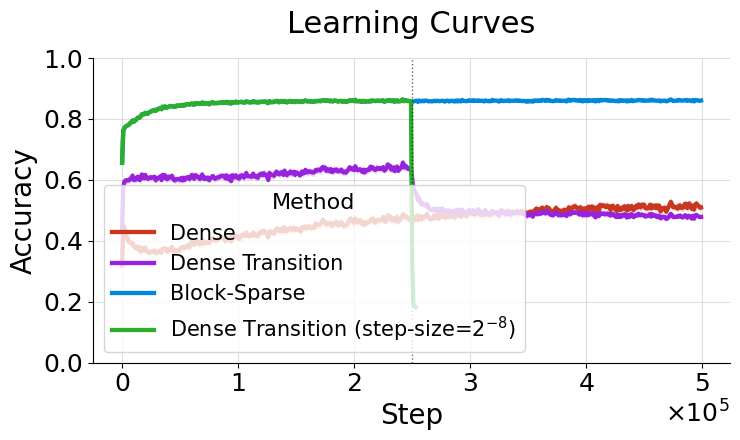

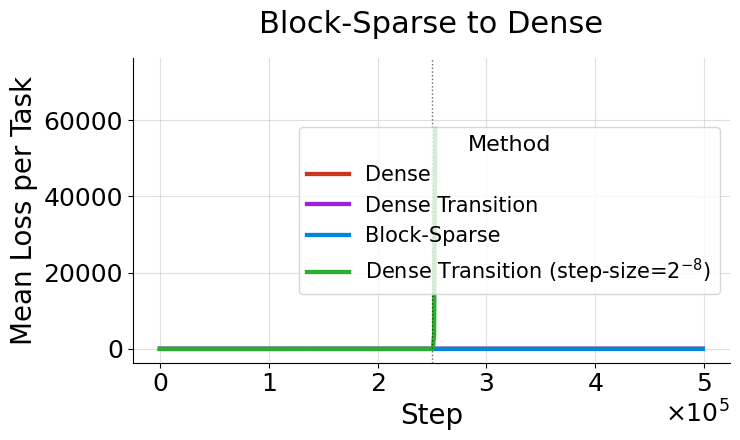

In [28]:
BLOCK_SPARSE_FS = 600000   # the "never fill" sentinel
DENSE_TRANSITION_FS = 250000

# Look up the step-size that won Block-Sparse (from `best`, already computed above).
lr_bs = best.loc[best['model.dense_fill_step'] == BLOCK_SPARSE_FS,
                 'optimizer.learning_rate'].iloc[0]

# Pull the Dense Transition trial(s) trained at that step-size (both seed_offset halves).
dt_at_bs_lr_cfg = df_cfg[
    (df_cfg['model.dense_fill_step'] == DENSE_TRANSITION_FS)
    & np.isclose(df_cfg['optimizer.learning_rate'], lr_bs)
]
dt_at_bs_lr_rids = dt_at_bs_lr_cfg['run_id'].tolist()
print(f'Block-Sparse best step-size: 2^{int(np.log2(lr_bs))} = {lr_bs:.6f}')
print(f'Dense Transition runs at that same step-size: {len(dt_at_bs_lr_rids)} '
      f'trial(s) (expect 2: seed_offset 0 and 15).')

# Fetch the per-seed assets for those extra runs (cached after first call).
extra_assets = fetch_per_seed_arrays(dt_at_bs_lr_rids)
asset_dict_ext = {**asset_dict, **extra_assets}

# Best-LR Dense Transition stays purple (FILL_STEP_PALETTE); the matched-LR
# variant gets green to set it apart on the same axis.
MATCHED_DT_COLOR = _PAL[2]    # green
matched_label = f'Dense Transition (step-size=$2^{{{int(np.log2(lr_bs))}}}$)'

import matplotlib.ticker as mticker

def _draw_all_curves(ax, accs_axis: bool):
    """Plot 4 curves: BS, Dense, DT-best-LR, DT-matched-LR."""
    for fs in sorted(best_cfg['model.dense_fill_step'].unique()):
        rids = best_cfg[best_cfg['model.dense_fill_step'] == fs]['run_id'].tolist()
        losses, accs = stack_per_seed(asset_dict_ext, rids)
        if losses is None:
            continue
        steps = np.arange(losses.shape[0]) * 1000
        method = FILL_STEP_LABELS[int(fs)]
        arr = accs if accs_axis else losses / 16
        plot_ci_curve(steps, arr, label=method,
                      color=FILL_STEP_PALETTE[method], ax=ax)
    # Extra: Dense Transition at the Block-Sparse best step-size.
    losses_dt2, accs_dt2 = stack_per_seed(asset_dict_ext, dt_at_bs_lr_rids)
    if losses_dt2 is not None:
        steps = np.arange(losses_dt2.shape[0]) * 1000
        arr = accs_dt2 if accs_axis else losses_dt2 / 16
        plot_ci_curve(steps, arr, label=matched_label,
                      color=MATCHED_DT_COLOR, ax=ax)
    ax.axvline(250000, linestyle=':', color='black', alpha=0.6, linewidth=1)

    # Remove the custom `ax.xaxis.set_major_formatter(_x_fmt)`
    # Use the default scientific notation formatting instead:
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.set_xlabel('Step')
    ax.grid(True, alpha=0.4)

# --- Accuracy ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
_draw_all_curves(ax, accs_axis=True)
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves')
ax.set_ylim(0, 1)
# Put the legend back inside the plot (default position)
ax.legend(loc='best', title='Method')
plt.tight_layout()
save_fig('dense_fill_main_accuracy_matched_lr')
plt.show()

# --- Per-task loss ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
_draw_all_curves(ax, accs_axis=False)
ax.set_ylabel('Mean Loss per Task')
ax.set_title('Block-Sparse to Dense')
# Put the legend back inside the plot (default position)
ax.legend(loc='best', title='Method')
plt.tight_layout()
save_fig('dense_fill_main_loss_matched_lr')
plt.show()

## 2. n_task_scaling: 4-method comparison

All four methods sweep `task.n_tasks ∈ {2,4,8,16,32}` × a size axis × LRs. The size axis differs by method:

| Method | Size axis | Grid |
|---|---|---|
| Block-Sparse | `model.initial_hidden_units` | 4, 8, ..., 512 |
| Dense | `model.initial_hidden_units` | 4, 8, ..., 512 |
| Random-Sparse | `model.initial_hidden_units` | 48, 96, ..., 1536 (per-unit sparsity fixed at 03 winner) |
| Structure-Search | `structure_search.connection_budget` | 4764, ..., 152448 (max_hidden/prune/units proportional) |

In [29]:
METHODS = [
    ('n_block_sparse',     'Block-Sparse',     'model.initial_hidden_units'),
    ('n_dense',            'Dense',            'model.initial_hidden_units'),
    ('n_random_sparse',    'Random-Sparse',    'model.initial_hidden_units'),
    ('n_structure_search', 'Structure-Search', 'structure_search.connection_budget'),
]
METHOD_PALETTE = get_color_palette(classes=[m[1] for m in METHODS])

for key, label, size_col in METHODS:
    c, r = filter_sweep(key)
    print(f'{label:18s}  trials={len(c):4d}  sizes={sorted(c[size_col].dropna().unique().tolist())}')

Block-Sparse        trials= 136  sizes=[4, 8, 16, 32, 64, 128, 256, 512]
Dense               trials= 160  sizes=[4, 8, 16, 32, 64, 128, 256, 512]
Random-Sparse       trials= 120  sizes=[48, 96, 192, 384, 768, 1536]
Structure-Search    trials= 120  sizes=[4764, 9528, 19056, 38112, 76224, 152448]


### 2a. Per-method: asymptotic accuracy vs size, hue = n_tasks (best LR per cell)

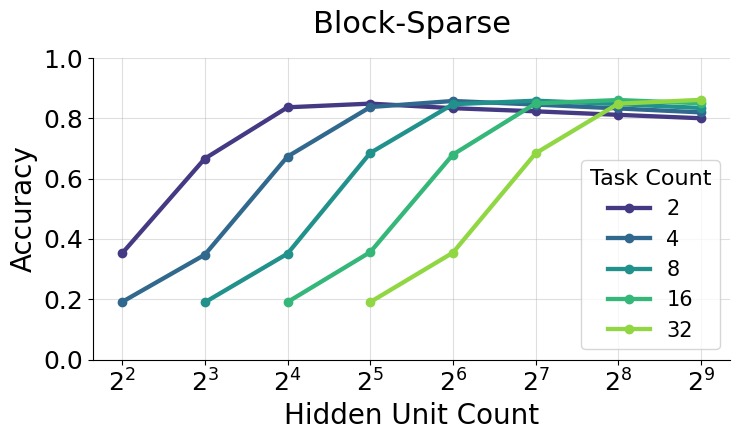

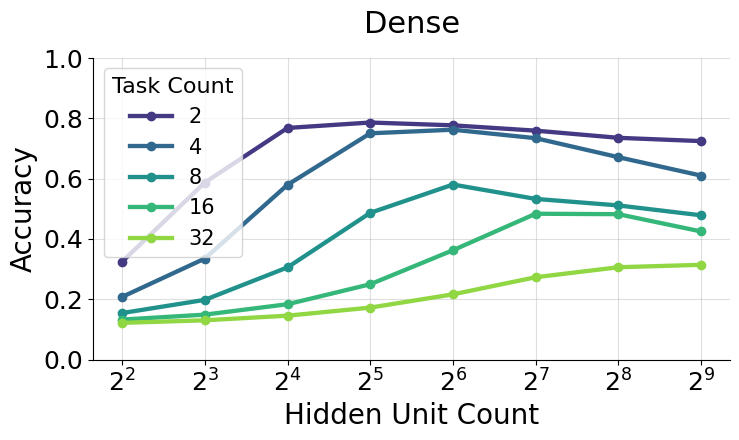

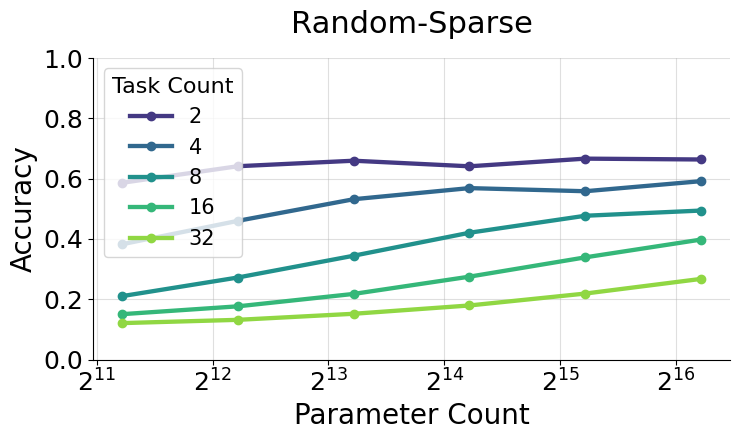

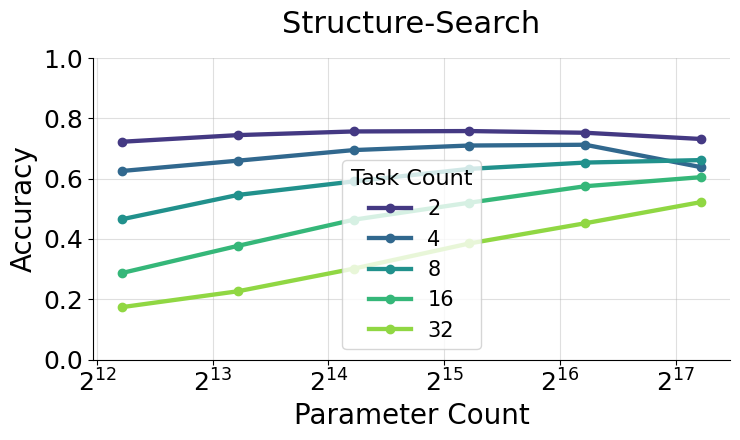

In [30]:
# For random_sparse, the swept axis is units but the fair "size" knob is
# the resulting parameter count (per-unit cost stays fixed at 03 winner =
# 49.625 weights/unit). Convert so the x-axis reads as parameter count,
# matching structure_search where connection_budget IS parameter count.
RANDOM_SPARSE_PER_UNIT = 49.625

# X-axis label and units differ per method: the first two methods plot
# hidden-unit count directly; the last two plot a weight-budget axis.
METHOD_X_AXES = {
    'n_block_sparse':     {'col': 'model.initial_hidden_units',        'xlabel': 'Hidden Unit Count'},
    'n_dense':            {'col': 'model.initial_hidden_units',        'xlabel': 'Hidden Unit Count'},
    'n_random_sparse':    {'col': 'model.initial_hidden_units',        'xlabel': 'Parameter Count',
                           'transform': lambda h: h * RANDOM_SPARSE_PER_UNIT},
    'n_structure_search': {'col': 'structure_search.connection_budget','xlabel': 'Parameter Count'},
}

for key, label, _ in METHODS:
    spec = METHOD_X_AXES[key]
    size_col = spec['col']
    xlabel = spec['xlabel']
    transform = spec.get('transform', lambda v: v)

    cfg, run = filter_sweep(key)
    if len(cfg) == 0:
        continue
    asym = asymptotic_metric(cfg, run, 'accuracy',
                             group_cols=['task.n_tasks', size_col])
    # idxmax may return NaN for groups whose every LR diverged; drop those
    # before .loc so pandas doesn't raise '[nan] not in index'.
    idxs = asym.groupby(['task.n_tasks', size_col])['_metric'].idxmax().dropna()
    best_grid = asym.loc[idxs.astype(int)].sort_values(['task.n_tasks', size_col])
    best_grid['_x'] = transform(best_grid[size_col])

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    n_palette = sns.color_palette('viridis',
                                  n_colors=best_grid['task.n_tasks'].nunique())
    for color, (n_t, sub) in zip(n_palette, best_grid.groupby('task.n_tasks')):
        ax.plot(sub['_x'], sub['_metric'], '-o',
                color=color, label=f'{int(n_t)}')
    ax.set_xscale('log', base=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.4)
    ax.legend(loc='best', title='Task Count')
    plt.tight_layout()
    save_fig(f'n_task_scaling_acc_vs_size_{key}')
    plt.show()

### 2b. Cross-method: best-tuned asymptotic accuracy vs n_tasks

For each method, picks the best `(size, LR)` combination at each `n_tasks` value and plots that single point. Direct head-to-head.

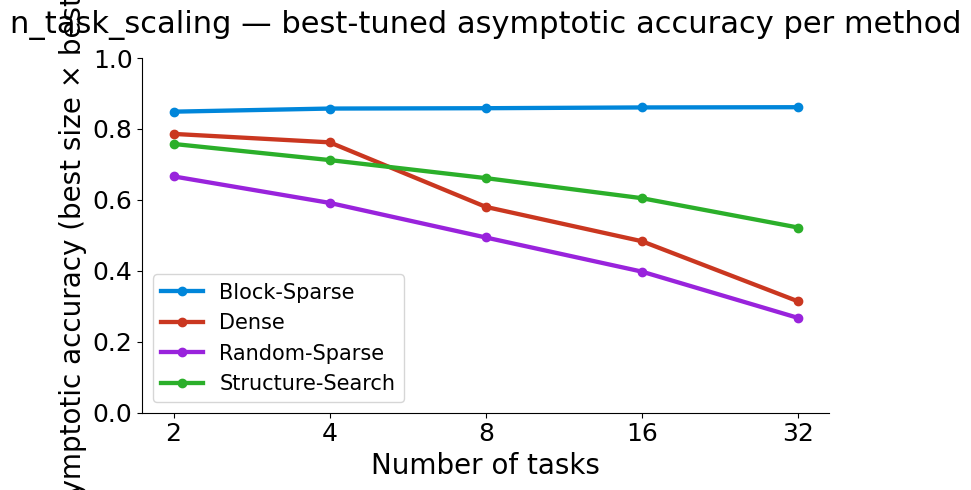

,Method,n_tasks,size,lr,asym_acc
0,Block-Sparse,2,32.0,0.003906,0.848700
1,Block-Sparse,4,64.0,0.003906,0.857486
2,Block-Sparse,8,128.0,0.003906,0.858463
3,Block-Sparse,16,256.0,0.003906,0.860618
4,Block-Sparse,32,512.0,0.003906,0.861270
5,Dense,2,32.0,0.001953,0.786020
6,Dense,4,64.0,0.001953,0.762208
7,Dense,8,64.0,0.001953,0.580320
8,Dense,16,128.0,0.000488,0.483485
9,Dense,32,512.0,0.000488,0.314118


In [31]:
records = []
for key, label, size_col in METHODS:
    cfg, run = filter_sweep(key)
    if len(cfg) == 0:
        continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=['task.n_tasks', size_col])
    idxs = asym.groupby(['task.n_tasks'])['_metric'].idxmax().dropna()
    best = asym.loc[idxs.astype(int)]
    for _, r in best.iterrows():
        records.append({
            'Method': label, 'n_tasks': int(r['task.n_tasks']),
            'size': r[size_col], 'lr': r['optimizer.learning_rate'], 'asym_acc': r['_metric'],
        })
df_best = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
for label in [m[1] for m in METHODS]:
    sub = df_best[df_best['Method'] == label].sort_values('n_tasks')
    plt.plot(sub['n_tasks'], sub['asym_acc'], '-o',
             color=METHOD_PALETTE[label], label=label)
plt.xscale('log', base=2)
plt.xticks([2, 4, 8, 16, 32], [2, 4, 8, 16, 32])
plt.xlabel('Number of tasks')
plt.ylabel('Asymptotic accuracy (best size × best LR)')
plt.title('n_task_scaling — best-tuned asymptotic accuracy per method')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
save_fig('n_task_scaling_cross_method_best')
plt.show()

df_best

### 2c. Cross-method learning curves with 95% CI (n_tasks = 4, best size × best LR per method)

Per-seed `.npy` assets feed the CI bands. 5 atomic seeds per trial.

fetch per-seed: 100%|██████████| 1/1 [00:00<00:00, 3123.09it/s]


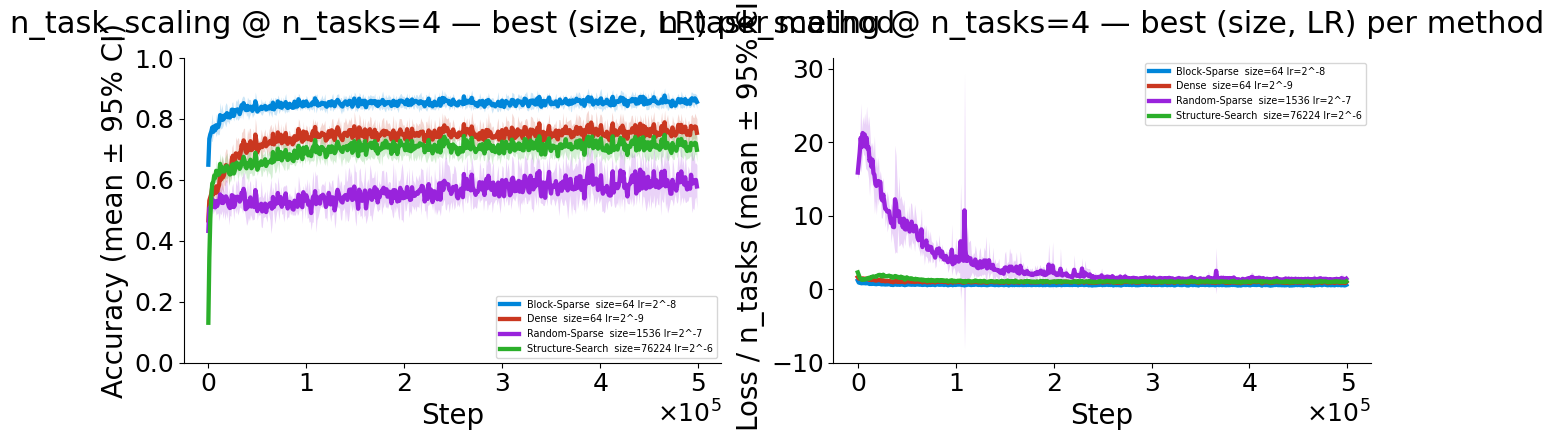

In [32]:
TARGET_N_TASKS = 4
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, label, size_col in METHODS:
    cfg, run = filter_sweep(key)
    cfg = cfg[cfg['task.n_tasks'] == TARGET_N_TASKS].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=[size_col])
    if asym['_metric'].notna().sum() == 0:
        continue
    row = asym.loc[asym['_metric'].idxmax()]
    best_size, best_lr = row[size_col], row['optimizer.learning_rate']
    rids = cfg[(cfg[size_col] == best_size)
               & (cfg['optimizer.learning_rate'] == best_lr)]['run_id'].tolist()
    assets = fetch_per_seed_arrays(rids)
    losses, accs = stack_per_seed(assets, rids)
    if losses is None:
        continue
    steps = np.arange(losses.shape[0]) * 1000
    lr_log2 = int(np.log2(best_lr))
    legend = f'{label}  size={int(best_size)} lr=2^{lr_log2}'
    plot_ci_curve(steps, accs, label=legend, color=METHOD_PALETTE[label], ax=axes[0])
    plot_ci_curve(steps, losses / TARGET_N_TASKS, label=legend, color=METHOD_PALETTE[label], ax=axes[1])
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Accuracy (mean ± 95% CI)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss / n_tasks (mean ± 95% CI)')
for ax in axes:
    # useMathText renders the offset as ×10⁵ (bottom-right) instead of `1e5`.
    import matplotlib.ticker as mticker
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axes[0].set_title(f'n_task_scaling @ n_tasks={TARGET_N_TASKS} — best (size, LR) per method')
axes[1].set_title(f'n_task_scaling @ n_tasks={TARGET_N_TASKS} — best (size, LR) per method')
axes[0].legend(fontsize='x-small', loc='best')
axes[1].legend(fontsize='x-small', loc='best')
axes[0].set_ylim(0, 1)
plt.tight_layout()
save_fig('n_task_scaling_curves_n4')
plt.show()

### 2d. LR-sensitivity per method (n_tasks = 4)

Verifies the LR grid spans the optimum at one representative n_tasks. Each panel shows asymptotic accuracy vs LR with hue = size axis.

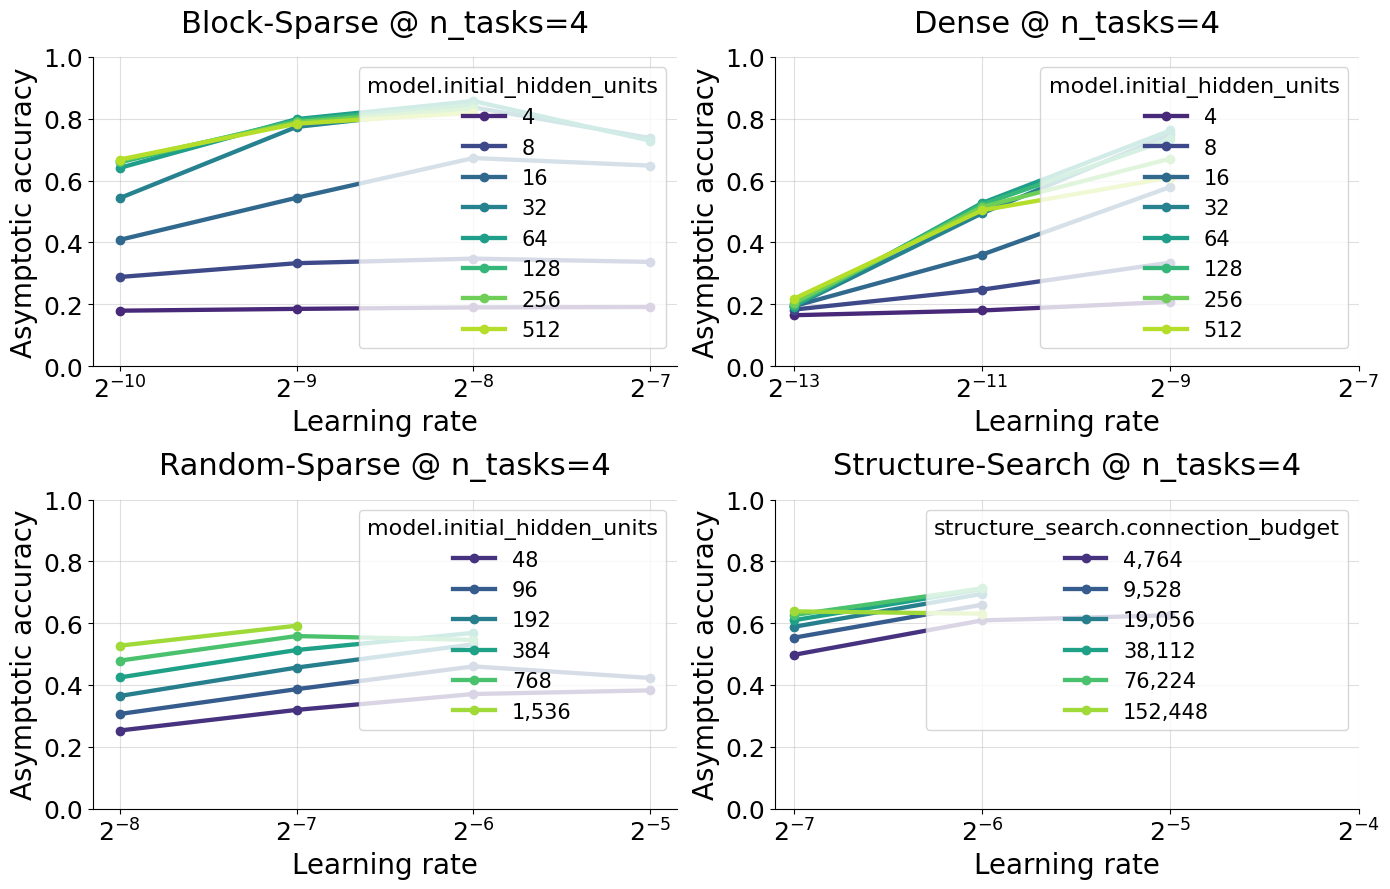

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (key, label, size_col) in zip(axes.flatten(), METHODS):
    cfg, run = filter_sweep(key)
    cfg = cfg[cfg['task.n_tasks'] == TARGET_N_TASKS].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        ax.set_title(f'{label} — no data'); continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=[size_col])
    n_sizes = asym[size_col].nunique()
    palette = sns.color_palette('viridis', n_colors=n_sizes)
    plot_lr_sensitivity(
        asym, ax=ax,
        hue_col=size_col, palette=palette,
        title=f'{label} @ n_tasks={TARGET_N_TASKS}',
        xlabel='Learning rate', ylabel='Asymptotic accuracy',
        ylim=(0, 1), legend_title=size_col,
    )
plt.tight_layout()
save_fig('n_task_scaling_lr_sensitivity_n4')
plt.show()